## Topic 1: Introduction to Functional API & Need for Non-Linear Topologies

---

### 1. Introduction

**What is the Functional API?**

The Functional API is an alternative way to build neural networks in Keras. Unlike the Sequential API (which you've likely used before), the Functional API allows you to create **non-linear** neural network architectures.

**Why is it important?**
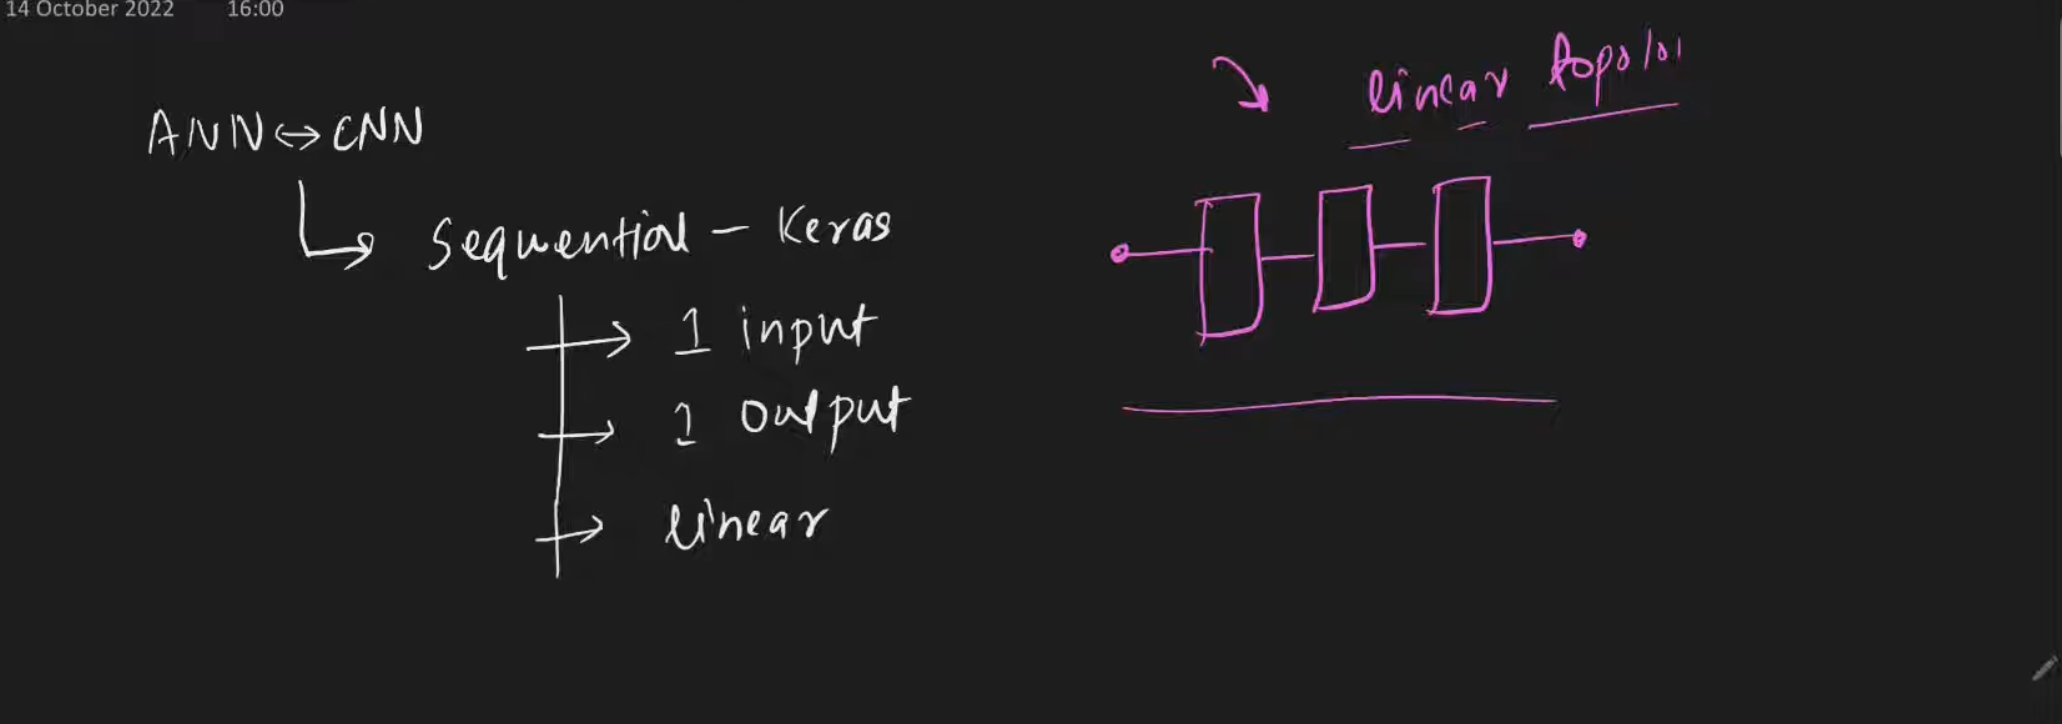
All the neural networks you've built so far using the Sequential API follow a **linear topology** – layers are stacked one after another in a straight line (input → hidden → hidden → output). But many real-world problems are more complex and require:

- **Multiple inputs** (different types of data coming from different sources)
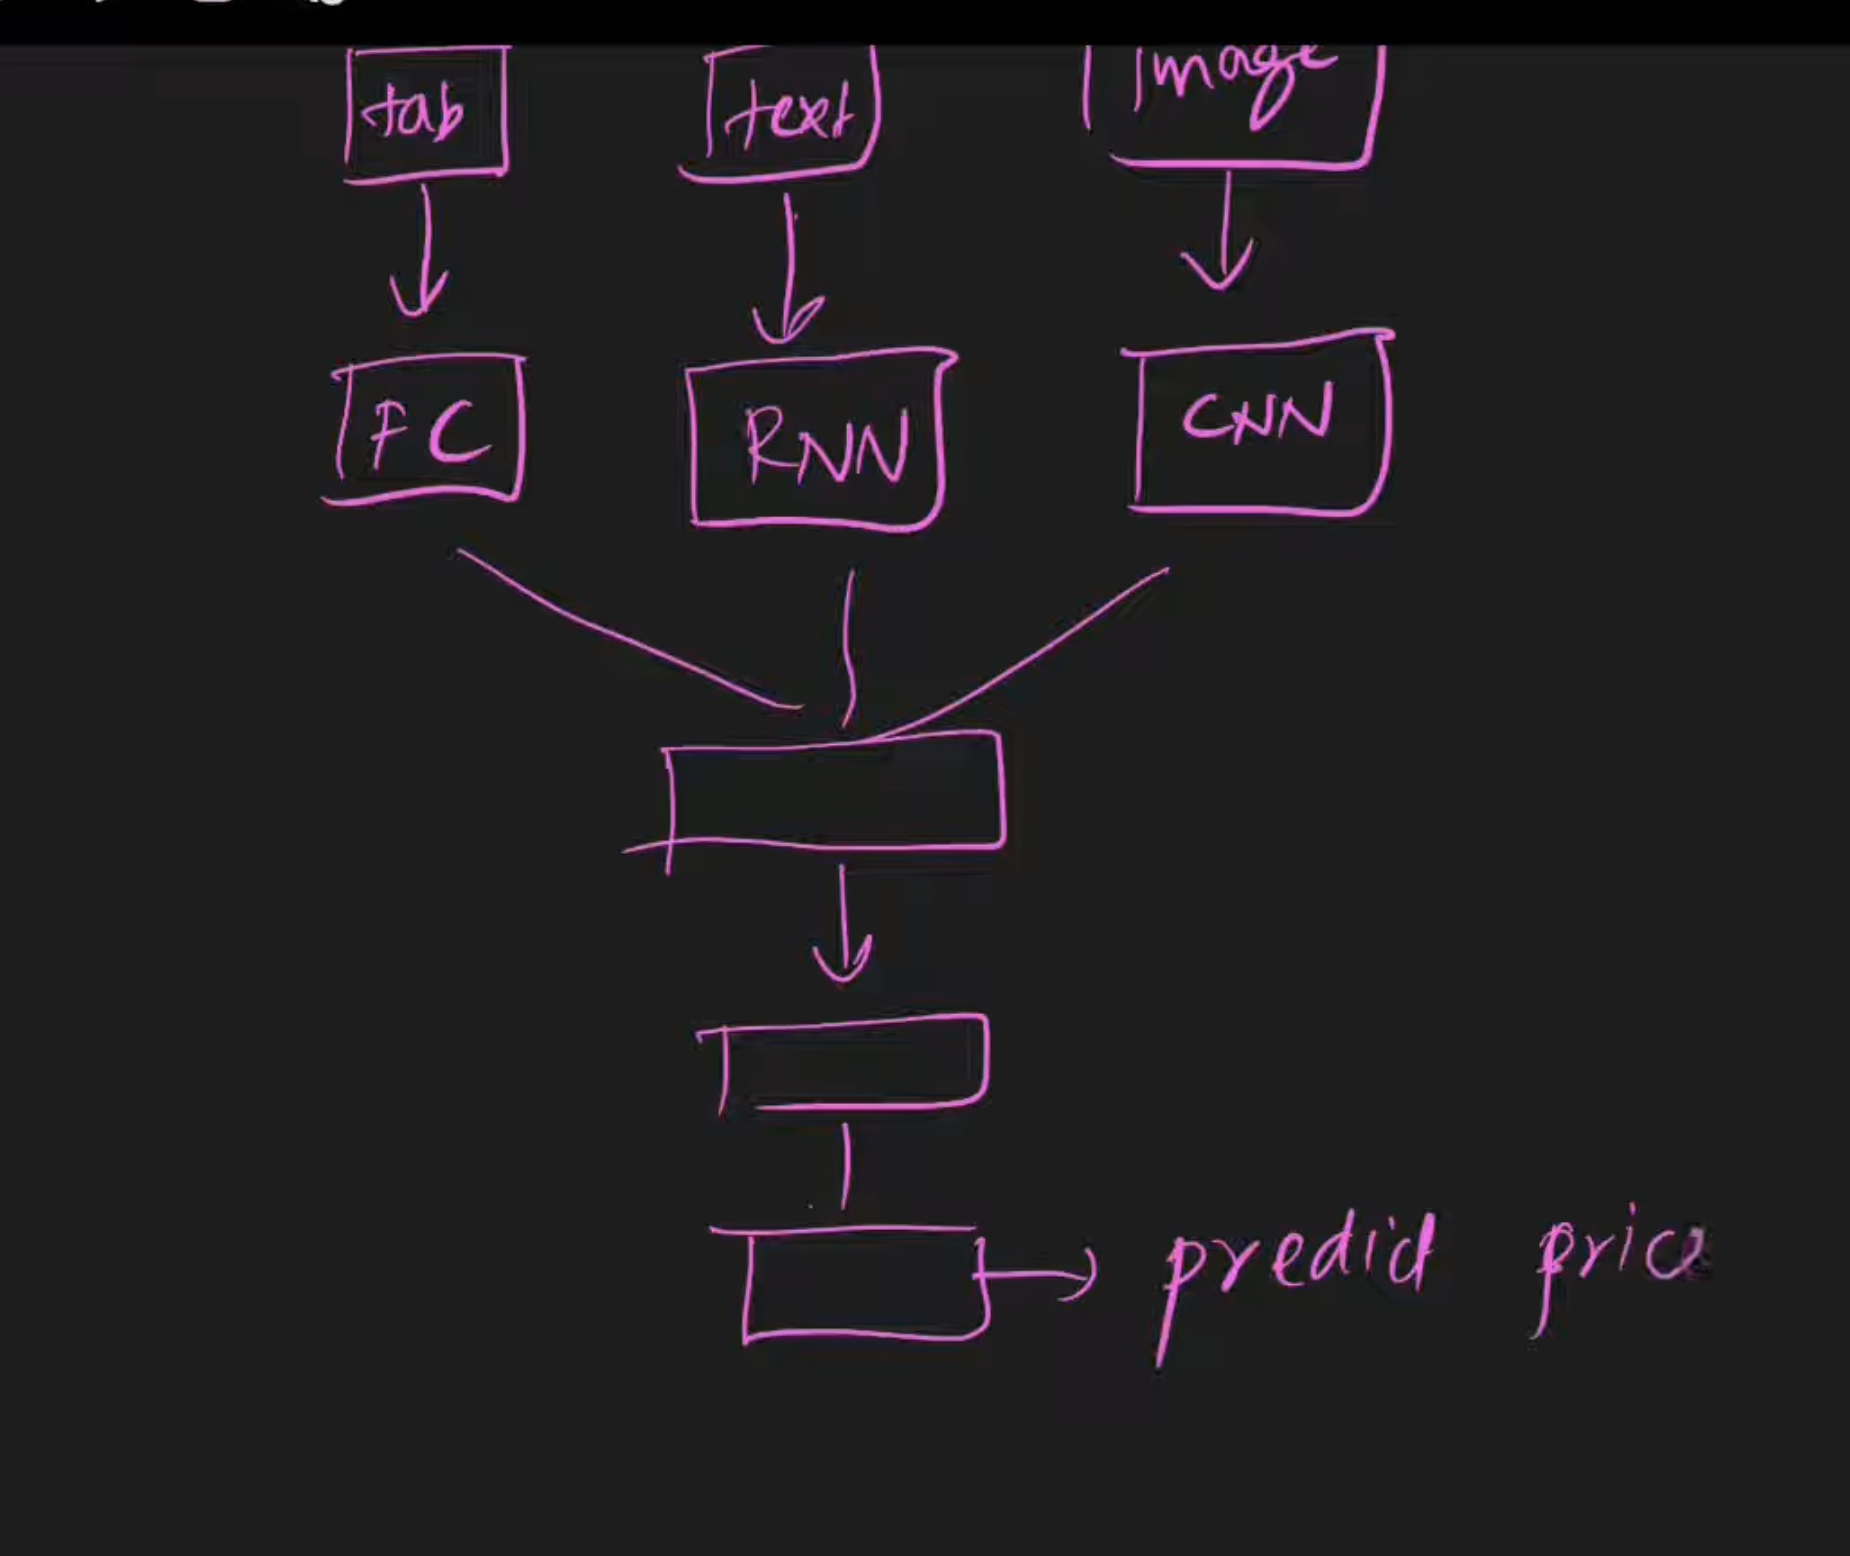
- **Multiple outputs** (predicting several things at once)
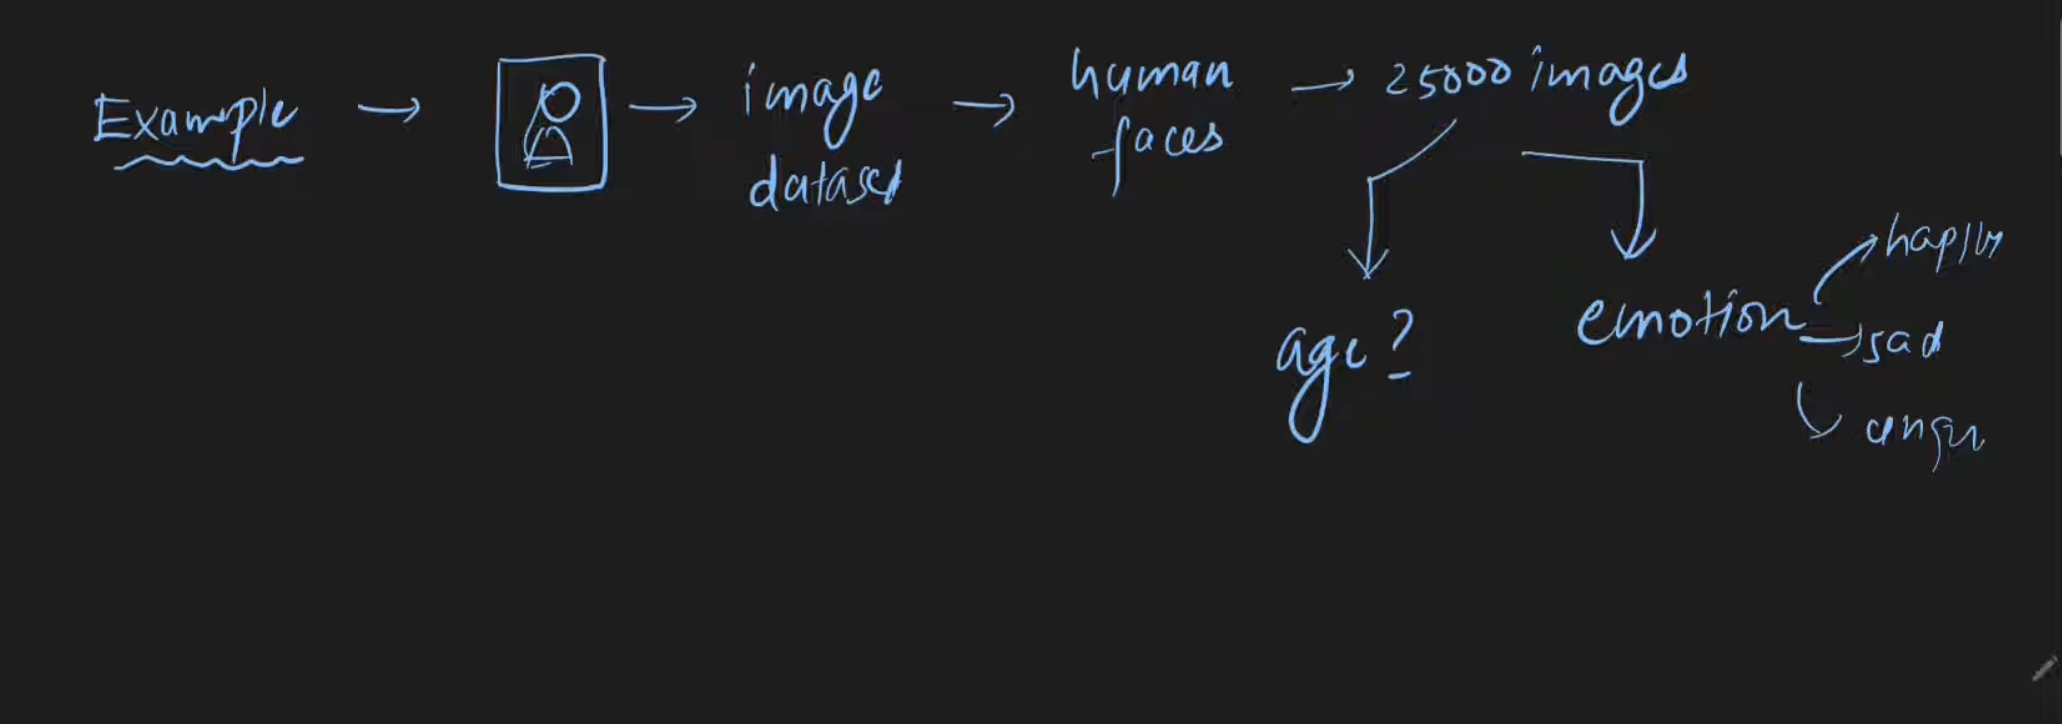
- **Shared layers** (reusing the same layer in different parts of the network)
- **Branching architectures** (splitting the network into different paths)

The Functional API gives you the flexibility to build **any kind of neural network topology** you can imagine.

**Real-life Use Cases:**

1. **Face Image Analysis** – You have an image of a person's face. You want to predict **both** their age **and** their emotion (happy, sad, angry) from the same image. This requires two separate outputs branching from a shared feature extractor.

2. **E-commerce Price Prediction** – You want to predict a product's price using:
   - Tabular data (color, size, category)
   - Text data (product description)
   - Image data (product photos)
   
   Each data type needs to be processed by a different type of neural network (Dense layers for tabular, RNN/LSTM for text, CNN for images), and their outputs must be combined to make a single prediction. This requires **multiple inputs**.

---

### 2. Detailed Explanation

**The Problem with Sequential API**

The Sequential API assumes your model is a simple stack of layers:
```
Input → Layer 1 → Layer 2 → Layer 3 → Output
```

This works perfectly when your problem follows a linear flow. However, consider these scenarios:

**Scenario A: Multiple Outputs (Branching)**

Imagine you're building a model that takes an image of a person and predicts:
1. The person's age
2. The person's gender

Both predictions should come from the same underlying image features. The architecture would look like:

```
                    ┌→ Dense → Age Output
Input → CNN → Flatten ┤
                    └→ Dense → Gender Output
```

This is a **branching topology** – the network splits into two paths after extracting shared features.

**Scenario B: Multiple Inputs (Convergence)**

Imagine you're building a model that predicts house prices using:
1. Numerical data (size, number of rooms, year built)
2. Text data (neighborhood description)
3. Image data (photos of the house)

Each input type needs a different processing path, and they all converge to make the final prediction:

```
Numerical Input → Dense Layers ┐
Text Input → Embedding → RNN   ├→ Concatenate → Dense → Price Output
Image Input → CNN → Flatten    ┘
```

This is a **converging topology** – multiple paths come together.

**The Solution: Functional API**

The Functional API treats layers as **callable functions** that you connect explicitly. Instead of just adding layers in order, you define the connections between layers using a functional syntax.

> **Key Concept:** In the Functional API, you explicitly tell each layer which previous layer it receives input from. This gives you complete control over the flow of data.

---

### 3. Key Points

- The **Sequential API** is limited to linear, single-input, single-output models
- The **Functional API** supports:
  - Multiple inputs (different data types)
  - Multiple outputs (multiple prediction tasks)
  - Non-linear topologies (branching, merging, sharing)
  - Complex architectures like Siamese networks, residual networks, etc.
- In Functional API, layers are connected by **explicitly passing the previous layer** as an argument
- The `Model` class is used instead of `Sequential`, and you define both the input and output layers when creating the model
- Imagination is the limit – you can create **any** neural network architecture with the Functional API

---

### 4. Syntax/Structure (Functional API Basics)

To use the Functional API, follow these steps:

**Step 1: Import the Model class**
```python
from keras.models import Model
```

**Step 2: Import layers**
```python
from keras.layers import Input, Dense, Flatten, Concatenate
# (import whatever layers you need)
```

**Step 3: Define the Input layer**
```python
input_tensor = Input(shape=(input_shape,))
```

**Step 4: Build the network by connecting layers**
```python
x = Dense(64, activation='relu', name='hidden1')(input_tensor)
x = Dense(32, activation='relu', name='hidden2')(x)
output = Dense(1, activation='linear', name='output')(x)
```

Notice the syntax: `Dense(...)(previous_layer)` – the layer is called as a function on the previous layer.

**Step 5: Create the model**
```python
model = Model(inputs=input_tensor, outputs=output)
```

**Step 6: Compile and train as usual**
```python
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10)
```

---

### 5. Code Examples

**Example 1: Simple Linear Model using Functional API**

```python
from keras.models import Model
from keras.layers import Input, Dense

# Define the input layer (3 features)
input_layer = Input(shape=(3,), name='input_layer')

# Hidden layer with 64 neurons
hidden1 = Dense(64, activation='relu', name='hidden1')(input_layer)

# Hidden layer with 32 neurons
hidden2 = Dense(32, activation='relu', name='hidden2')(hidden1)

# Output layer (1 neuron for regression)
output_layer = Dense(1, activation='linear', name='output')(hidden2)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)

# Summary
model.summary()
```

**Explanation:**
- `Input(shape=(3,))` defines the input shape (3 features)
- Each `Dense` layer is called with the previous layer as an argument
- `Model(inputs=..., outputs=...)` ties everything together
- This model is functionally equivalent to a Sequential model, but written in the Functional style

---

### 6. Output

When you call `model.summary()`, you'll see:

```
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
input_layer (InputLayer)     [(None, 3)]               0         
_________________________________________________________________
hidden1 (Dense)              (None, 64)                256       
_________________________________________________________________
hidden2 (Dense)              (None, 32)                2080      
_________________________________________________________________
output (Dense)               (None, 1)                 33        
=================================================================
Total params: 2,369
Trainable params: 2,369
Non-trainable params: 0
_________________________________________________________________
```

**Step-by-step explanation of the output:**
1. **InputLayer** – Takes input of shape (3,). "None" means batch size is flexible.
2. **hidden1** – Dense layer with 64 neurons. Parameters = 3×64 + 64 = 256.
3. **hidden2** – Dense layer with 32 neurons. Parameters = 64×32 + 32 = 2080.
4. **output** – Dense layer with 1 neuron. Parameters = 32×1 + 1 = 33.

---

### 7. Common Mistakes

| Mistake | Why it's wrong | How to avoid |
|---------|---------------|--------------|
| Forgetting to pass the previous layer as an argument | `Dense(64)(input_layer)` is correct; `Dense(64)` alone just creates an unconnected layer | Always use `LayerName(params)(previous_layer)` syntax |
| Using `Sequential` instead of `Model` | `Sequential` doesn't support non-linear topologies | Use `from keras.models import Model` and `Model(inputs=..., outputs=...)` |
| Not specifying `Input` layer separately | You need an explicit `Input` object to define the input shape | Always start with `Input(shape=(...))` |
| Forgetting to name layers (optional but recommended) | Naming helps with debugging and model visualization | Use `name='layer_name'` in each layer |
| Not passing both inputs when using multiple inputs | `Model(inputs=[input1, input2], outputs=...)` requires a list | Use lists: `inputs=[...]` and `outputs=[...]` |

---

### 8. Interview/Exam Questions

**Q1: What is the main difference between Sequential API and Functional API in Keras?**

**A:** The Sequential API is limited to linear stacks of layers (one input, one output, no branching). The Functional API allows you to build non-linear topologies with multiple inputs, multiple outputs, shared layers, and branching/merging architectures.

**Q2: When would you choose the Functional API over the Sequential API?**

**A:** You would choose the Functional API when:
- Your model has multiple inputs (different data types)
- Your model has multiple outputs (multi-task learning)
- You need branching or merging of layers
- You want to share layers between different parts of the network
- You need to build complex architectures like Siamese networks or residual networks

**Q3: Write the code to create a simple neural network with one input layer, one hidden layer with 64 neurons and ReLU activation, and one output layer with 1 neuron (regression) using the Functional API.**

**A:**
```python
from keras.models import Model
from keras.layers import Input, Dense

inputs = Input(shape=(10,))
x = Dense(64, activation='relu')(inputs)
outputs = Dense(1, activation='linear')(x)
model = Model(inputs=inputs, outputs=outputs)
```

**Q4: What does the syntax `Dense(64)(input_layer)` mean in the Functional API?**

**A:** It means create a Dense layer with 64 units and connect it to `input_layer`. The `input_layer` is passed as an argument to the Dense layer, establishing that the output of `input_layer` becomes the input to this Dense layer.

---

### 9. Revision Notes

- **Sequential API** = linear only (input → layer1 → layer2 → output)
- **Functional API** = any topology (multiple inputs, outputs, branching, sharing)
- **Key syntax:** `layer = Dense(units, activation)(previous_layer)`
- **Model creation:** `model = Model(inputs=input_layer, outputs=output_layer)`
- **Use cases for Functional API:**
  - Multi-task learning (predict age + gender from one image)
  - Multi-modal learning (tabular + text + image inputs)
  - Complex architectures with branches
- **Always import:** `from keras.models import Model` and `from keras.layers import Input`
- **Naming layers** is optional but recommended for clarity and visualization
- The Functional API gives you **complete flexibility** to design any neural network architecture

---



## Topic 2: Building a Multi-Output Model (Branching Architecture)

---

### 1. Introduction

**What is a Multi-Output Model?**

A multi-output model is a neural network that predicts **two or more different things** from the same input. Instead of having a single output layer at the end, the network branches into multiple paths, each producing its own prediction.

**Why is it important?**

In many real-world applications, you want to extract multiple pieces of information from a single data point. For example:
- From a person's face image, you might want to predict **both age and gender**
- From a product description, you might want to predict **both price and category**
- From sensor data, you might want to predict **both temperature and humidity**

Training a single multi-output model is often **better than training separate models** because:
1. The shared layers learn **general features** that benefit all tasks
2. It's more **computationally efficient** (one forward pass instead of multiple)
3. It often leads to **better generalization** because tasks provide complementary information

**Real-life Use Case: Face Analysis**

You have a dataset of human face images. Each image has two labels:
- **Age** (a continuous number, e.g., 25, 34, 42)
- **Gender** (binary: male or female)

Instead of building two separate CNNs (one for age, one for gender), you build **one CNN** that shares the feature extraction layers and then branches into two separate output layers.

---

### 2. Detailed Explanation

**The Architecture: A Shared Backbone with Branches**

Think of this architecture as a **tree**:

```
                    ┌→ Dense (Age) → Output (Age Regression)
Input → Dense(64) → Dense(32) ┤
                    └→ Dense (Gender) → Output (Gender Classification)
```

**Step-by-step flow:**

1. **Input layer** – Receives the raw data (e.g., tabular data with 3 features)
2. **Shared hidden layers** – These layers process the input and learn general patterns. All branches share these layers.
3. **Branching point** – After the shared layers, the network splits into two (or more) separate paths
4. **Branch-specific layers** – Each branch has its own layers tailored to its specific prediction task
5. **Output layers** – Each branch produces its own prediction

**Why This Works:**

The shared layers learn **features that are useful for both tasks**. For example, in face analysis:
- Early CNN layers learn edges and textures (useful for both age and gender)
- Middle layers learn facial features like eye shape and skin texture (useful for both)
- The branches then specialize: one branch learns how these features relate to age, another learns how they relate to gender

**Key Concepts:**

| Term | Meaning |
|------|---------|
| **Shared layers** | Layers that are common to all outputs. They are trained using gradients from all tasks simultaneously. |
| **Branch** | A separate path in the network dedicated to one specific output. |
| **Multi-task learning** | Training a model to perform multiple related tasks at the same time. |
| **Loss weighting** | Giving different importance to different tasks (e.g., age prediction might be weighted more heavily than gender). |

---

### 3. Key Points

- Multiple outputs are created by **branching** the network at some point
- The **shared layers** learn features that benefit all tasks
- Each branch has its own **dense layers and output layer**
- In the Functional API, you define **multiple output layers** and pass them as a list to the `Model` class
- When compiling, you need to specify **multiple loss functions** (one per output)
- The `loss_weights` parameter allows you to give different importance to different tasks
- Multi-output models are a form of **multi-task learning**

---

### 4. Syntax/Structure (Multi-Output Model)

**Step 1: Define the input layer**
```python
input_layer = Input(shape=(3,), name='input')
```

**Step 2: Build shared layers**
```python
shared1 = Dense(64, activation='relu', name='shared1')(input_layer)
shared2 = Dense(32, activation='relu', name='shared2')(shared1)
```

**Step 3: Create branches (each branch is a separate output)**
```python
# Branch 1: Predict age (regression - linear activation)
age_dense = Dense(1, activation='linear', name='age_dense')(shared2)
age_output = Dense(1, activation='linear', name='age_output')(age_dense)

# Branch 2: Predict gender (classification - sigmoid for binary)
gender_dense = Dense(1, activation='sigmoid', name='gender_dense')(shared2)
gender_output = Dense(1, activation='sigmoid', name='gender_output')(gender_dense)
```

**Step 4: Create the model with multiple outputs**
```python
model = Model(inputs=input_layer, outputs=[age_output, gender_output])
```

**Step 5: Compile with multiple losses**
```python
model.compile(
    optimizer='adam',
    loss={
        'age_output': 'mse',        # Regression loss
        'gender_output': 'binary_crossentropy'  # Classification loss
    },
    loss_weights={
        'age_output': 1.0,          # Equal importance
        'gender_output': 1.0
    }
)
```

**Step 6: Train with multiple targets**
```python
# y_train should be a list or dictionary with both targets
model.fit(X_train, {'age_output': y_age_train, 'gender_output': y_gender_train}, epochs=10)
```

---

### 5. Code Examples

**Complete Example: Predicting Age and Gender from Tabular Data**

```python
import numpy as np
from keras.models import Model
from keras.layers import Input, Dense

# --- 1. Generate dummy data ---
# 1000 samples, 3 features each
X_train = np.random.rand(1000, 3)

# Age labels (regression target)
y_age_train = np.random.randint(18, 65, size=(1000, 1))

# Gender labels (binary classification: 0=male, 1=female)
y_gender_train = np.random.randint(0, 2, size=(1000, 1))

# --- 2. Build the model ---
# Input layer (3 features)
input_layer = Input(shape=(3,), name='input_layer')

# Shared hidden layers
shared1 = Dense(64, activation='relu', name='shared1')(input_layer)
shared2 = Dense(32, activation='relu', name='shared2')(shared1)

# Branch 1: Age prediction (regression)
age_hidden = Dense(16, activation='relu', name='age_hidden')(shared2)
age_output = Dense(1, activation='linear', name='age_output')(age_hidden)

# Branch 2: Gender prediction (binary classification)
gender_hidden = Dense(16, activation='relu', name='gender_hidden')(shared2)
gender_output = Dense(1, activation='sigmoid', name='gender_output')(gender_hidden)

# Create the model
model = Model(inputs=input_layer, outputs=[age_output, gender_output])

# --- 3. Compile the model ---
model.compile(
    optimizer='adam',
    loss={
        'age_output': 'mse',
        'gender_output': 'binary_crossentropy'
    },
    loss_weights={
        'age_output': 1.0,
        'gender_output': 1.0
    },
    metrics={
        'age_output': ['mae'],
        'gender_output': ['accuracy']
    }
)

# --- 4. Display model summary ---
model.summary()

# --- 5. Train the model ---
history = model.fit(
    X_train,
    {'age_output': y_age_train, 'gender_output': y_gender_train},
    epochs=10,
    batch_size=32,
    verbose=1
)

# --- 6. Make predictions ---
# New sample
X_new = np.random.rand(1, 3)
predictions = model.predict(X_new)

# predictions[0] = age prediction
# predictions[1] = gender prediction (probability)
print(f"Predicted age: {predictions[0][0][0]:.2f}")
print(f"Predicted gender probability (0=male, 1=female): {predictions[1][0][0]:.4f}")
```

**Explanation of key parts:**

| Code | Purpose |
|------|---------|
| `Dense(1, activation='linear')` | Regression output (age can be any number) |
| `Dense(1, activation='sigmoid')` | Binary classification output (gender: 0 or 1) |
| `loss={'age_output': 'mse', ...}` | Different loss functions for different outputs |
| `metrics={'age_output': ['mae'], ...}` | Different metrics to monitor |
| `model.predict()` returns a list | Each element corresponds to one output branch |

---

### 6. Output

**Model Summary:**

```
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
==================================================================================================
input_layer (InputLayer)        [(None, 3)]          0                                           
__________________________________________________________________________________________________
shared1 (Dense)                 (None, 64)           256         input_layer[0][0]                
__________________________________________________________________________________________________
shared2 (Dense)                 (None, 32)           2080        shared1[0][0]                    
__________________________________________________________________________________________________
age_hidden (Dense)              (None, 16)           528         shared2[0][0]                    
__________________________________________________________________________________________________
gender_hidden (Dense)           (None, 16)           528         shared2[0][0]                    
__________________________________________________________________________________________________
age_output (Dense)              (None, 1)            17          age_hidden[0][0]                 
__________________________________________________________________________________________________
gender_output (Dense)           (None, 1)            17          gender_hidden[0][0]              
==================================================================================================
Total params: 3,426
Trainable params: 3,426
Non-trainable params: 0
__________________________________________________________________________________________________
```

**Training Output (epoch 1 example):**
```
Epoch 1/10
32/32 [==============================] - 1s 4ms/step - loss: 156.2347 - age_output_loss: 155.9823 - gender_output_loss: 0.2524 - age_output_mae: 11.2345 - gender_output_accuracy: 0.5120
```

**Interpretation:**
- `loss`: Total loss = weighted sum of both losses (155.98 + 0.25 = 156.23)
- `age_output_loss`: Mean squared error for age (high initially)
- `gender_output_loss`: Binary crossentropy for gender (0.69 is random chance)
- `age_output_mae`: Mean absolute error for age (~11 years off initially)
- `gender_output_accuracy`: Accuracy for gender (~50% is random chance)

---

### 7. Common Mistakes

| Mistake | Explanation | How to Avoid |
|---------|-------------|--------------|
| Using wrong activation for output | Linear for regression, sigmoid/softmax for classification | Use `linear` for regression, `sigmoid` for binary classification, `softmax` for multi-class |
| Not specifying multiple losses | Compiling with a single loss gives an error | Use `loss={'output1': 'loss1', 'output2': 'loss2'}` or a list |
| Not matching training data structure | `fit()` expects data in the same format as `outputs` | Provide targets as a list or dictionary matching output names |
| Forgetting `loss_weights` | Default weights are 1.0, but you may want to balance tasks | Set `loss_weights` to balance tasks if one loss dominates |
| Using same name for different layers | Causes ambiguity when plotting or saving | Give each layer a unique `name` |

---

### 8. Interview/Exam Questions

**Q1: What is multi-task learning and why is it beneficial?**

**A:** Multi-task learning is training a single model to perform multiple related tasks simultaneously. It's beneficial because:
- Shared layers learn general features useful for all tasks
- It's computationally more efficient than training separate models
- Tasks provide complementary information, often leading to better generalization
- It reduces overfitting as the model learns more robust representations

**Q2: How do you create a model with two outputs using the Functional API?**

**A:** 
```python
input_layer = Input(shape=(10,))
x = Dense(64, activation='relu')(input_layer)
output1 = Dense(1, activation='linear', name='output1')(x)
output2 = Dense(1, activation='sigmoid', name='output2')(x)
model = Model(inputs=input_layer, outputs=[output1, output2])
```

**Q3: What loss functions would you use for a model that predicts both age (continuous) and gender (binary)?**

**A:** 
- Age: Mean Squared Error (`'mse'`) or Mean Absolute Error (`'mae'`) for regression
- Gender: Binary Crossentropy (`'binary_crossentropy'`) for binary classification

**Q4: Why might you use `loss_weights` in a multi-output model?**

**A:** Because different tasks may have losses on different scales (e.g., MSE for age could be ~100, while crossentropy for gender could be ~0.7). Without weighting, the model will focus on optimizing the larger loss and ignore the smaller one. `loss_weights` balances the contribution of each task to the total loss.

---

### 9. Revision Notes

- **Multi-output models** predict multiple things from one input
- **Architecture pattern**: Shared layers → Branch into task-specific layers → Outputs
- **Branching** is achieved by connecting different dense layers to the same shared layer
- **Compilation** requires a loss function for each output (`loss={'output1': 'loss1', ...}`)
- **Training data** must match the outputs (list or dictionary of targets)
- **Predictions** return a list where each element corresponds to one output
- **Loss weights** balance the importance of different tasks
- This is a powerful pattern for **real-world applications** where you want to extract multiple insights from the same data

---



## Topic 3: Building a Multi-Input Model (Converging Architecture)

---

### 1. Introduction

**What is a Multi-Input Model?**

A multi-input model is a neural network that takes **two or more different types of input** and combines them to make a single prediction. Instead of having one input layer, the network has multiple input branches, each processing a different type of data, which then merge together before making the final prediction.

**Why is it important?**

In the real world, data comes in many forms. For example, when predicting a product's price, you might have:
- **Tabular data**: product size, color, category, brand
- **Text data**: product description, customer reviews
- **Image data**: product photos

Each type of data requires a different processing approach:
- Tabular data → Dense (fully connected) layers
- Text data → RNN, LSTM, or Embedding layers
- Image data → CNN layers

A multi-input model allows you to process each data type with the most appropriate neural network architecture and then combine their learned features to make a final prediction.

**Real-life Use Case: E-commerce Price Prediction**

You're building a model to predict product prices for an e-commerce startup. For each product, you have three types of information:
1. **Product metadata** (tabular): color, size, category, brand
2. **Product description** (text): a detailed description from the website
3. **Product image** (image): photos of the product

By combining information from all three sources, you can make a much more accurate price prediction than using any single source alone.

---

### 2. Detailed Explanation

**The Architecture: Multiple Input Branches that Converge**

Think of this architecture as a **funnel**:

```
Tabular Data → Dense Layers ┐
                             ├→ Concatenate → Dense Layers → Output (Price)
Text Data → Embedding → RNN ┘
Image Data → CNN → Flatten  ┘
```

**Step-by-step flow:**

1. **Multiple input layers** – Each input type has its own Input layer with appropriate shape
2. **Branch-specific processing** – Each input goes through layers designed for that data type:
   - Tabular: Dense layers
   - Text: Embedding → RNN/LSTM
   - Image: Conv2D → Pooling → Flatten
3. **Concatenation (merging)** – The outputs from all branches are combined into a single vector
4. **Shared layers** – The concatenated features pass through dense layers to learn interactions between different data types
5. **Output layer** – Final prediction

**Why This Works:**

Different data types contain **complementary information**. For price prediction:
- Metadata gives you the basic product category
- Description text gives you quality indicators and features
- Image gives you visual cues about the product's condition and appearance

By combining all three, the model can make a more informed prediction than any single source could provide.

**Key Concepts:**

| Term | Meaning |
|------|---------|
| **Multi-modal learning** | Learning from multiple types of data (modalities) simultaneously |
| **Concatenation** | Merging multiple vectors by joining them together end-to-end |
| **Embedding** | Converting categorical/text data into dense numerical vectors |
| **Branch-specific processing** | Using different layer types for different input types because they work best for that data |

---

### 3. Key Points

- Multiple inputs are created by defining **multiple Input layers**
- Each input branch processes its data **independently** using appropriate layers
- Branches are combined using a **merge/concatenate layer**
- After merging, the network continues with **shared dense layers**
- The Functional API allows you to pass multiple inputs as a **list** to the `Model` class
- Different input types require different layer types for optimal performance
- This pattern is called **multi-modal learning** or **data fusion**

---

### 4. Syntax/Structure (Multi-Input Model)

**Step 1: Define multiple input layers**
```python
# Input A: Tabular data (e.g., 3 features)
input_a = Input(shape=(3,), name='input_a')

# Input B: Text data (e.g., sequence of 100 words)
input_b = Input(shape=(100,), name='input_b')

# Input C: Image data (e.g., 64x64 RGB image)
input_c = Input(shape=(64, 64, 3), name='input_c')
```

**Step 2: Process each input with appropriate layers**
```python
# Branch A: Tabular → Dense layers
x_a = Dense(32, activation='relu', name='dense_a1')(input_a)
x_a = Dense(16, activation='relu', name='dense_a2')(x_a)

# Branch B: Text → Embedding → LSTM
x_b = Embedding(vocab_size, 50, name='embedding_b')(input_b)
x_b = LSTM(32, name='lstm_b')(x_b)

# Branch C: Image → CNN → Flatten
x_c = Conv2D(32, (3,3), activation='relu', name='conv_c1')(input_c)
x_c = MaxPooling2D((2,2), name='pool_c1')(x_c)
x_c = Conv2D(64, (3,3), activation='relu', name='conv_c2')(x_c)
x_c = MaxPooling2D((2,2), name='pool_c2')(x_c)
x_c = Flatten(name='flatten_c')(x_c)
x_c = Dense(16, activation='relu', name='dense_c')(x_c)
```

**Step 3: Concatenate all branches**
```python
# Combine all branches
combined = Concatenate(name='concatenate')([x_a, x_b, x_c])
```

**Step 4: Shared layers after concatenation**
```python
z = Dense(32, activation='relu', name='shared1')(combined)
z = Dense(16, activation='relu', name='shared2')(z)
output = Dense(1, activation='linear', name='output')(z)
```

**Step 5: Create the model with multiple inputs**
```python
model = Model(inputs=[input_a, input_b, input_c], outputs=output)
```

**Step 6: Compile and train with multiple inputs**
```python
model.compile(optimizer='adam', loss='mse')

# Training data must be provided as a list matching the input order
model.fit(
    [X_tabular_train, X_text_train, X_image_train],
    y_price_train,
    epochs=10
)
```

---

### 5. Code Examples

**Complete Example: Multi-Input Model for Price Prediction**

```python
import numpy as np
from keras.models import Model
from keras.layers import Input, Dense, Concatenate, Embedding, LSTM, Flatten
from keras.layers import Conv2D, MaxPooling2D

# --- 1. Generate dummy data ---
n_samples = 1000

# Input A: Tabular data (3 features: size, category, brand)
X_tabular = np.random.rand(n_samples, 3)

# Input B: Text data (sequences of 50 word indices)
X_text = np.random.randint(0, 100, size=(n_samples, 50))  # 100 vocabulary size

# Input C: Image data (32x32 grayscale images, 1 channel)
X_image = np.random.rand(n_samples, 32, 32, 1)

# Output: Price (regression target)
y_price = np.random.rand(n_samples, 1) * 1000  # Prices between 0-1000

# --- 2. Build the model ---

# Input A: Tabular branch
input_tabular = Input(shape=(3,), name='input_tabular')
x_tab = Dense(32, activation='relu', name='tabular_dense1')(input_tabular)
x_tab = Dense(16, activation='relu', name='tabular_dense2')(x_tab)

# Input B: Text branch
input_text = Input(shape=(50,), name='input_text')
x_text = Embedding(100, 20, name='text_embedding')(input_text)  # 100 vocab, 20 embedding dims
x_text = LSTM(32, name='text_lstm')(x_text)  # LSTM returns single vector
x_text = Dense(16, activation='relu', name='text_dense')(x_text)

# Input C: Image branch
input_image = Input(shape=(32, 32, 1), name='input_image')
x_img = Conv2D(32, (3, 3), activation='relu', name='conv1')(input_image)
x_img = MaxPooling2D((2, 2), name='pool1')(x_img)
x_img = Conv2D(64, (3, 3), activation='relu', name='conv2')(x_img)
x_img = MaxPooling2D((2, 2), name='pool2')(x_img)
x_img = Flatten(name='flatten_image')(x_img)
x_img = Dense(16, activation='relu', name='image_dense')(x_img)

# Merge all branches
combined = Concatenate(name='concatenate_layer')([x_tab, x_text, x_img])

# Shared layers after merging
z = Dense(32, activation='relu', name='shared_dense1')(combined)
z = Dense(16, activation='relu', name='shared_dense2')(z)

# Output layer
output = Dense(1, activation='linear', name='price_output')(z)

# Create the model
model = Model(inputs=[input_tabular, input_text, input_image], outputs=output)

# --- 3. Compile the model ---
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# --- 4. Display model summary ---
model.summary()

# --- 5. Train the model ---
history = model.fit(
    [X_tabular, X_text, X_image],
    y_price,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# --- 6. Make predictions ---
# New sample: one from each input type
new_tabular = np.random.rand(1, 3)
new_text = np.random.randint(0, 100, size=(1, 50))
new_image = np.random.rand(1, 32, 32, 1)

predicted_price = model.predict([new_tabular, new_text, new_image])
print(f"Predicted price: ${predicted_price[0][0]:.2f}")
```

**Explanation of key concepts:**

| Component | Purpose |
|-----------|---------|
| `Embedding(100, 20)` | Converts word indices (0-99) to 20-dimensional dense vectors |
| `LSTM(32)` | Processes sequential text data and returns a 32-dimensional vector |
| `Concatenate()` | Merges all branch outputs into one long vector |
| `Conv2D + MaxPooling2D` | Extracts features from image data |
| `loss='mse'` | Regression task (predicting price) |
| `metrics=['mae']` | Monitor mean absolute error during training |

---

### 6. Output

**Model Architecture Visualization (conceptual):**

```
┌─────────────────────────────────────────────────────────────┐
│                        Input Layers                        │
├──────────────┬──────────────────┬──────────────────────────┤
│ Input Tabular│   Input Text     │     Input Image          │
│    (3,)      │    (50,)         │     (32, 32, 1)          │
├──────────────┼──────────────────┼──────────────────────────┤
│   Dense(32)  │  Embedding(20)   │    Conv2D(32, 3x3)       │
│   Dense(16)  │  LSTM(32)        │    MaxPool(2x2)          │
│              │  Dense(16)       │    Conv2D(64, 3x3)       │
│              │                  │    MaxPool(2x2)          │
│              │                  │    Flatten               │
│              │                  │    Dense(16)             │
├──────────────┴──────────────────┴──────────────────────────┤
│                  Concatenate (48 features)                  │
│                   Dense(32) → Dense(16)                    │
│                        Output (1)                          │
└─────────────────────────────────────────────────────────────┘
```

**Model Summary (partial):**

```
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
==================================================================================================
input_tabular (InputLayer)      [(None, 3)]          0                                           
input_text (InputLayer)         [(None, 50)]         0                                           
input_image (InputLayer)        [(None, 32, 32, 1)]  0                                           
__________________________________________________________________________________________________
tabular_dense1 (Dense)          (None, 32)           128         input_tabular[0][0]              
tabular_dense2 (Dense)          (None, 16)           528         tabular_dense1[0][0]             
__________________________________________________________________________________________________
text_embedding (Embedding)      (None, 50, 20)       2000        input_text[0][0]                 
text_lstm (LSTM)                (None, 32)           6784        text_embedding[0][0]             
text_dense (Dense)              (None, 16)           528         text_lstm[0][0]                  
__________________________________________________________________________________________________
conv1 (Conv2D)                  (None, 30, 30, 32)   320         input_image[0][0]                
pool1 (MaxPooling2D)            (None, 15, 15, 32)   0           conv1[0][0]                      
conv2 (Conv2D)                  (None, 13, 13, 64)   18496       pool1[0][0]                      
pool2 (MaxPooling2D)            (None, 6, 6, 64)     0           conv2[0][0]                      
flatten_image (Flatten)         (None, 2304)         0           pool2[0][0]                      
image_dense (Dense)             (None, 16)           36880       flatten_image[0][0]              
__________________________________________________________________________________________________
concatenate_layer (Concatenate) (None, 48)           0           tabular_dense2[0][0]             
                                                                 text_dense[0][0]                 
                                                                 image_dense[0][0]                
__________________________________________________________________________________________________
shared_dense1 (Dense)           (None, 32)           1568        concatenate_layer[0][0]          
shared_dense2 (Dense)           (None, 16)           528         shared_dense1[0][0]              
price_output (Dense)            (None, 1)            17          shared_dense2[0][0]              
==================================================================================================
Total params: 67,777
Trainable params: 67,777
Non-trainable params: 0
__________________________________________________________________________________________________
```

---

### 7. Common Mistakes

| Mistake | Explanation | How to Avoid |
|---------|-------------|--------------|
| Mismatched input shapes in training | Passing inputs in wrong order or with wrong shapes | Ensure `X_train` is a list in the same order as `inputs=[...]` |
| Forgetting to flatten CNN output | CNN outputs multi-dimensional tensors that can't directly connect to Dense | Use `Flatten()` or `GlobalAveragePooling2D()` before Dense |
| Using incompatible layer types | e.g., LSTM expects sequential data, not tabular | Match layer type to input data type |
| Concatenating incompatible dimensions | All branches being concatenated must have compatible shapes | Ensure all branch outputs have the same batch dimension and appropriate feature dimensions |
| Not normalizing different input types | Different inputs may be on very different scales | Normalize/standardize each input type separately before training |
| Using `Concatenate` incorrectly | `Concatenate()([branch1, branch2])` needs a list | Pass a list: `Concatenate()([x1, x2, x3])` |

---

### 8. Interview/Exam Questions

**Q1: What is the difference between a multi-input model and a multi-output model?**

**A:** 
- **Multi-input model**: Takes multiple different inputs and produces one output (converging architecture)
- **Multi-output model**: Takes one input and produces multiple different outputs (branching architecture)
- They can be combined (multiple inputs, multiple outputs) for even more complex architectures

**Q2: Why would you use different types of layers for different inputs?**

**A:** Different data types have different structures and properties:
- Dense layers work well for structured/tabular data
- LSTM/RNN layers work well for sequential/text data
- CNN layers work well for spatial/grid data like images
Using the right layer type for each input allows the model to learn the most relevant features from each data modality.

**Q3: How do you merge branches in a multi-input model using the Functional API?**

**A:** Using the `Concatenate` layer:
```python
from keras.layers import Concatenate
merged = Concatenate()([branch1, branch2, branch3])
```
Other merge options include `Add()`, `Multiply()`, and `Average()` depending on the use case.

**Q4: Write the code to create a model that takes two inputs (tabular and text) and produces one output (classification).**

**A:**
```python
from keras.models import Model
from keras.layers import Input, Dense, Concatenate, Embedding, LSTM

# Tabular input
input1 = Input(shape=(5,), name='tabular_input')
x1 = Dense(32, activation='relu')(input1)

# Text input
input2 = Input(shape=(100,), name='text_input')
x2 = Embedding(1000, 50)(input2)
x2 = LSTM(32)(x2)

# Merge
merged = Concatenate()([x1, x2])
z = Dense(16, activation='relu')(merged)
output = Dense(1, activation='sigmoid', name='output')(z)

model = Model(inputs=[input1, input2], outputs=output)
```

---

### 9. Revision Notes

- **Multi-input models** combine different data types for better predictions
- Each input branch uses **appropriate layers** for its data type:
  - Tabular → Dense
  - Text → Embedding → LSTM/RNN
  - Images → CNN → Flatten
- Branches are merged using **Concatenate** (or Add, Multiply, Average)
- After merging, **shared dense layers** learn interactions between modalities
- **Model creation**: `Model(inputs=[input1, input2, ...], outputs=output)`
- **Training**: `model.fit([X1, X2, ...], y, ...)` - inputs must be in the same order
- This is called **multi-modal learning** or **data fusion**
- Real-world applications include self-driving cars (cameras + LiDAR + radar), healthcare (images + lab results + patient history), and e-commerce (metadata + text + images)

---



## Topic 4: Visualizing Model Architecture with `plot_model`

---

### 1. Introduction

**What is `plot_model`?**

`plot_model` is a utility function in Keras that allows you to **visualize your neural network architecture** as a diagram. It creates a graphical representation showing all the layers, their connections, and how data flows through the network.

**Why is it important?**

When you build complex models with:
- Multiple inputs
- Multiple outputs
- Branching paths
- Shared layers

It becomes **difficult to keep track of the architecture** just by reading code. A visual diagram helps you:

1. **Verify** that your model is built correctly
2. **Communicate** your architecture to others (team members, in presentations)
3. **Debug** connection issues (e.g., wrong layer order, incorrect branching)
4. **Document** your work for future reference

**Real-life Use Case: Model Documentation**

Imagine you're working on a research project with a complex multi-input, multi-output model. You need to present your architecture in a paper or to your team. Instead of describing it in words, you can generate a clear diagram that shows exactly how data flows through the network.

---

### 2. Detailed Explanation

**How `plot_model` Works**

`plot_model` takes your Keras `Model` object and generates a visual diagram where:

- **Boxes** represent layers
- **Arrows** represent connections (data flow)
- The diagram shows the **flow from inputs to outputs**

**Basic Syntax:**

```python
from keras.utils import plot_model

plot_model(model, to_file='model_architecture.png')
```

**Common Parameters:**

| Parameter | Purpose | Example |
|-----------|---------|---------|
| `model` | The Keras model to visualize | `plot_model(model, ...)` |
| `to_file` | Output filename (saves as image) | `to_file='my_model.png'` |
| `show_shapes` | Display input/output shapes | `show_shapes=True` |
| `show_layer_names` | Display layer names | `show_layer_names=True` |
| `show_layer_activations` | Display activation functions | `show_layer_activations=True` |
| `rankdir` | Direction of the diagram | `rankdir='LR'` (left to right) |
| `dpi` | Resolution of the image | `dpi=300` |

> **Note:** `plot_model` requires `pydot` and `graphviz` to be installed. You may need to install them separately.

---

### 3. Key Points

- `plot_model` generates a **visual diagram** of your Keras model
- It's especially useful for **complex, non-linear architectures**
- You can **customize** what information is displayed (shapes, layer names, activations)
- The diagram helps with **debugging, documentation, and communication**
- Requires `pydot` and `graphviz` libraries
- Can output to various image formats (PNG, JPG, SVG, etc.)
- The `rankdir='LR'` option makes the diagram flow **left to right** (more intuitive)

---

### 4. Syntax/Structure (Using `plot_model`)

**Step 1: Ensure dependencies are installed**

```bash
# Install required packages
pip install pydot
# graphviz needs to be installed separately:
# On Ubuntu: sudo apt-get install graphviz
# On Mac: brew install graphviz
# On Windows: Download from graphviz.org
```

**Step 2: Import and use `plot_model`**

```python
from keras.utils import plot_model

# After building your model
model = Model(inputs=..., outputs=...)

# Basic usage
plot_model(model, to_file='model.png')

# Advanced usage with all options
plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    rankdir='LR',          # Left to Right flow
    dpi=300                # High resolution
)
```

**Step 3: Display the image (in Jupyter Notebook)**

```python
from IPython.display import Image

# Display the saved image in notebook
Image('model_architecture.png')
```

---

### 5. Code Examples

**Example 1: Simple Linear Model Visualization**

```python
from keras.models import Model
from keras.layers import Input, Dense
from keras.utils import plot_model

# Build a simple model
inputs = Input(shape=(10,), name='input_layer')
x = Dense(64, activation='relu', name='hidden1')(inputs)
x = Dense(32, activation='relu', name='hidden2')(x)
outputs = Dense(1, activation='linear', name='output')(x)

model = Model(inputs=inputs, outputs=outputs)

# Generate visualization
plot_model(
    model,
    to_file='simple_model.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='LR'
)

print("Model visualization saved as 'simple_model.png'")
```

**Visual output (conceptual):**

```
┌──────────────┐    ┌─────────────┐    ┌─────────────┐    ┌──────────┐
│ input_layer  │ ─→ │   hidden1   │ ─→ │   hidden2   │ ─→ │  output  │
│ InputLayer   │    │  Dense(64)  │    │  Dense(32)  │    │ Dense(1) │
│ shape: (10)  │    │ act: relu   │    │ act: relu   │    │ act: lin │
└──────────────┘    └─────────────┘    └─────────────┘    └──────────┘
```

---

**Example 2: Multi-Output Model Visualization (Branching)**

```python
from keras.models import Model
from keras.layers import Input, Dense
from keras.utils import plot_model

# Build multi-output model
inputs = Input(shape=(5,), name='input_layer')
shared = Dense(32, activation='relu', name='shared_layer')(inputs)

# Branch 1: Age prediction
age_output = Dense(1, activation='linear', name='age_output')(shared)

# Branch 2: Gender prediction
gender_output = Dense(1, activation='sigmoid', name='gender_output')(shared)

model = Model(inputs=inputs, outputs=[age_output, gender_output])

# Visualize with shapes
plot_model(
    model,
    to_file='multi_output_model.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='LR'
)

print("Multi-output model saved as 'multi_output_model.png'")
```

**Visual output (conceptual):**

```
                    ┌──────────────────┐
                    │   age_output     │
                    │  Dense(1) linear │
                    └──────────────────┘
                    ↑
┌──────────────┐    ┌──────────────┐    
│ input_layer  │ ─→ │ shared_layer │
│ InputLayer   │    │  Dense(32)   │
│ shape: (5)   │    │ act: relu    │
└──────────────┘    └──────────────┘    
                    ↓
                    ┌──────────────────────┐
                    │   gender_output      │
                    │  Dense(1) sigmoid    │
                    └──────────────────────┘
```

---

**Example 3: Multi-Input Model Visualization (Converging)**

```python
from keras.models import Model
from keras.layers import Input, Dense, Concatenate, Embedding, LSTM, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model

# Build multi-input model
input_tabular = Input(shape=(3,), name='tabular_input')
x_tab = Dense(16, activation='relu', name='tabular_dense')(input_tabular)

input_text = Input(shape=(50,), name='text_input')
x_text = Embedding(100, 20, name='text_embedding')(input_text)
x_text = LSTM(16, name='text_lstm')(x_text)

input_image = Input(shape=(28, 28, 1), name='image_input')
x_img = Conv2D(16, (3, 3), activation='relu', name='conv1')(input_image)
x_img = MaxPooling2D((2, 2), name='pool1')(x_img)
x_img = Flatten(name='image_flatten')(x_img)
x_img = Dense(16, activation='relu', name='image_dense')(x_img)

# Merge
merged = Concatenate(name='merge')([x_tab, x_text, x_img])
z = Dense(16, activation='relu', name='shared')(merged)
output = Dense(1, activation='linear', name='price_output')(z)

model = Model(inputs=[input_tabular, input_text, input_image], outputs=output)

# Visualize with all options
plot_model(
    model,
    to_file='multi_input_model.png',
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    rankdir='LR',
    dpi=200
)

print("Multi-input model saved as 'multi_input_model.png'")
```

**Visual output (conceptual):**

```
┌────────────────┐    ┌──────────────────┐
│ tabular_input  │ ─→ │ tabular_dense    │
│ InputLayer(3)  │    │ Dense(16) relu   │
└────────────────┘    └──────────────────┘
                                       ↓
┌────────────────┐    ┌──────────────────┐    ┌──────────────┐    ┌─────────────────┐
│ text_input     │ ─→ │ text_embedding   │ ─→ │ text_lstm    │ ─→ │   merge         │
│ InputLayer(50) │    │ Embedding(100,20)│    │ LSTM(16)     │    │ Concatenate     │
└────────────────┘    └──────────────────┘    └──────────────┘    └─────────────────┘
                                                                           ↓
┌────────────────┐    ┌──────────────────┐    ┌──────────────────┐    ┌─────────────────┐
│ image_input    │ ─→ │ conv1            │ ─→ │ pool1            │ ─→ │ image_dense     │
│ InputLayer(28, │    │ Conv2D(16,3x3)   │    │ MaxPooling(2x2)  │    │ Dense(16) relu  │
│ 28, 1)         │    │ relu             │    │                  │    │                 │
└────────────────┘    └──────────────────┘    └──────────────────┘    └─────────────────┘
                                                                           ↓
                                                              ┌─────────────────────┐
                                                              │ price_output        │
                                                              │ Dense(1) linear     │
                                                              └─────────────────────┘
```

---

### 6. Output

When you run `plot_model`, it creates an image file. Here's what you'd see in the console:

```
Model visualization saved as 'model_architecture.png'
```

**If dependencies are missing:**

```
Could not import pydot. You must install pydot and graphviz for plot_model to work.
```

**In a Jupyter Notebook, you can display the image:**

```python
from IPython.display import Image
Image('model_architecture.png')
```

---

### 7. Common Mistakes

| Mistake | Explanation | How to Avoid |
|---------|-------------|--------------|
| Forgetting to install dependencies | `plot_model` requires pydot and graphviz | Install: `pip install pydot` and install graphviz system package |
| Missing `to_file` parameter | `plot_model(model)` without filename raises error | Always specify `to_file='filename.png'` |
| File path issues | Trying to save to a directory that doesn't exist | Ensure the output directory exists or use a relative path |
| Not using `show_shapes=True` | Without this, the diagram shows only layer names | Enable `show_shapes=True` for more informative diagrams |
| Diagram too crowded | Too many layers make the image unreadable | Use `show_shapes=True` but consider `rankdir='TB'` for top-to-bottom flow if left-to-right is too wide |
| Using `plot_model` before compiling | The model object works fine even before compilation | You can call `plot_model` anytime after building the model |

---

### 8. Interview/Exam Questions

**Q1: What is the purpose of the `plot_model` function in Keras?**

**A:** `plot_model` is used to generate a visual diagram of a Keras model's architecture. It shows layers, connections, shapes, and other details, helping with debugging, documentation, and communication of complex models.

**Q2: What dependencies are required for `plot_model` to work?**

**A:** `plot_model` requires:
- `pydot` (Python package): `pip install pydot`
- `graphviz` (system package): installed separately via system package manager

**Q3: How can you display input/output shapes in the model diagram?**

**A:** Set the `show_shapes=True` parameter when calling `plot_model`:
```python
plot_model(model, to_file='model.png', show_shapes=True)
```

**Q4: What does the `rankdir` parameter control and what are its possible values?**

**A:** `rankdir` controls the direction of the diagram flow:
- `'LR'` (Left to Right) – horizontal flow (default with `show_shapes=True`)
- `'TB'` (Top to Bottom) – vertical flow
- `'RL'` (Right to Left)
- `'BT'` (Bottom to Top)

---

### 9. Revision Notes

- **`plot_model`** creates a visual diagram of your Keras model architecture
- **Import**: `from keras.utils import plot_model`
- **Basic usage**: `plot_model(model, to_file='model.png')`
- **Key parameters**:
  - `to_file`: Output filename
  - `show_shapes`: Show input/output dimensions
  - `show_layer_names`: Show layer names (default: True)
  - `show_layer_activations`: Show activation functions
  - `rankdir`: Flow direction ('LR' for left-to-right)
  - `dpi`: Image resolution (higher = clearer but larger file)
- **Dependencies**: pydot + graphviz must be installed
- **Best for**: Complex models with multiple inputs, outputs, or branches
- **Benefits**: Debugging, documentation, team communication
- **The diagram** shows the complete data flow from inputs through all layers to outputs
- When `show_shapes=True`, each layer shows its output shape, helping verify dimensions

---



## Topic 5: Advanced Example – Transfer Learning with Functional API (VGG16 + Multi-Output)

---

### 1. Introduction

**What is Transfer Learning with Functional API?**

Transfer learning is a technique where you take a pre-trained neural network (trained on a large dataset like ImageNet) and use it as a **feature extractor** for your own task. When combined with the Functional API, you can:
- Take the pre-trained convolutional base (like VGG16)
- Attach custom branches for **multiple outputs** (e.g., age + gender prediction)
- Fine-tune the model for your specific multi-task problem

**Why is it important?**

Training a deep CNN from scratch requires:
- **Massive amounts of data** (millions of images)
- **Extensive computational resources** (days/weeks of training time)
- **Expertise** in tuning deep networks

Transfer learning solves these problems by leveraging **pre-trained features** that are already good at recognizing general patterns (edges, textures, shapes, objects). You only need to train the final layers for your specific task.

**Real-life Use Case: Face Image Analysis (UTKFace Dataset)**

The **UTKFace dataset** contains images of human faces with:
- **Age** (e.g., 25, 34, 42)
- **Gender** (0 = male, 1 = female)
- The filename encodes this information (e.g., `25_0_...` means age=25, gender=male)

Instead of training a CNN from scratch on this dataset, you:
1. Use **VGG16** pre-trained on ImageNet as the feature extractor
2. Remove the top classification layers
3. Add **two branches**:
   - One for age regression (linear activation)
   - One for gender classification (sigmoid activation)
4. Train only the added layers (or fine-tune the last few layers)

---

### 2. Detailed Explanation

**Step-by-Step Architecture**

Here's how the full model is built:

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                         VGG16 Convolutional Base                          │
│              (Pre-trained on ImageNet, weights frozen or fine-tuned)      │
│                                                                           │
│  Input Image (200x200x3)                                                  │
│       ↓                                                                   │
│  Conv2D(64) → Conv2D(64) → MaxPool                                       │
│  Conv2D(128) → Conv2D(128) → MaxPool                                     │
│  Conv2D(256) → Conv2D(256) → Conv2D(256) → MaxPool                       │
│  Conv2D(512) → Conv2D(512) → Conv2D(512) → MaxPool                       │
│  Conv2D(512) → Conv2D(512) → Conv2D(512) → MaxPool                       │
│       ↓                                                                   │
│  Output: Feature Map (shape depends on input size)                       │
└─────────────────────────────────────────────────────────────────────────────┘
                                    ↓
┌─────────────────────────────────────────────────────────────────────────────┐
│                         Added Custom Layers                               │
│                                                                           │
│  Flatten layer: Converts feature map to a 1D vector                       │
│       ↓                                                                   │
│  Dense(512) with ReLU activation (shared features)                        │
│       ↓                                                                   │
│  ┌─────────────────────────┐         ┌─────────────────────────────────┐ │
│  │ Branch 1: Age Prediction │         │  Branch 2: Gender Prediction   │ │
│  │ (Regression)             │         │  (Binary Classification)       │ │
│  │                          │         │                                 │ │
│  │ Dense(512) → ReLU       │         │  Dense(512) → ReLU             │ │
│  │ Dense(1) → Linear       │         │  Dense(1) → Sigmoid            │ │
│  │ (Age output)            │         │  (Gender output)               │ │
│  └─────────────────────────┘         └─────────────────────────────────┘ │
└─────────────────────────────────────────────────────────────────────────────┘
```

**Key Points about This Architecture:**

1. **Feature Extraction**: VGG16's convolutional layers have learned to detect edges, textures, shapes, and object parts from ImageNet. These features are useful for face-related tasks too.

2. **Shared Features**: Both age and gender predictions use the same features from VGG16. This is efficient and helps both tasks perform better.

3. **Task-Specific Branches**: After extracting features, the network branches into two separate paths, each optimized for its specific task.

4. **Transfer Learning Benefits**: By using pre-trained weights, you need far fewer training examples to get good performance.

---

### 3. Key Points

- **VGG16** is a popular pre-trained CNN architecture (16 layers deep)
- **`include_top=False`** removes the final fully connected layers (ImageNet classifier)
- The **convolutional base** acts as a fixed feature extractor (or can be fine-tuned)
- **Flatten** converts the 2D feature map to a 1D vector
- **Two separate branches** are created for age and gender prediction
- The model has **multiple outputs** (age and gender)
- **Loss functions** are different for each output:
  - Age: Mean Squared Error (`mse`)
  - Gender: Binary Crossentropy (`binary_crossentropy`)
- Data augmentation helps improve generalization with limited data

---

### 4. Syntax/Structure (Loading VGG16 and Building Custom Model)

**Step 1: Import VGG16 and remove top layers**

```python
from keras.applications import VGG16

# Load VGG16 without the final classification layers
# include_top=False removes the last 3 dense layers
# input_shape must match your image size (e.g., 200x200x3)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))
```

**Step 2: Freeze the base model weights (optional but recommended)**

```python
# Freeze all VGG16 layers so they don't get updated during training
base_model.trainable = False
```

**Step 3: Define the input and add custom layers**

```python
from keras.models import Model
from keras.layers import Input, Flatten, Dense, Dropout

# Input layer (image)
input_layer = Input(shape=(200, 200, 3), name='input_image')

# Pass input through VGG16 base
x = base_model(input_layer)

# Flatten the feature maps
x = Flatten(name='flatten')(x)

# Shared dense layer
x = Dense(512, activation='relu', name='shared_dense')(x)
x = Dropout(0.5, name='shared_dropout')(x)

# Branch 1: Age (regression)
age_dense = Dense(512, activation='relu', name='age_dense')(x)
age_output = Dense(1, activation='linear', name='age_output')(age_dense)

# Branch 2: Gender (binary classification)
gender_dense = Dense(512, activation='relu', name='gender_dense')(x)
gender_output = Dense(1, activation='sigmoid', name='gender_output')(gender_dense)
```

**Step 4: Create the model**

```python
model = Model(inputs=input_layer, outputs=[age_output, gender_output])
```

**Step 5: Compile with appropriate losses**

```python
model.compile(
    optimizer='adam',
    loss={
        'age_output': 'mse',
        'gender_output': 'binary_crossentropy'
    },
    loss_weights={
        'age_output': 1.0,
        'gender_output': 1.0
    },
    metrics={
        'age_output': ['mae'],
        'gender_output': ['accuracy']
    }
)
```

---

### 5. Code Examples

**Complete Example: VGG16 + Multi-Output Model**

```python
import numpy as np
from keras.applications import VGG16
from keras.models import Model
from keras.layers import Input, Flatten, Dense, Dropout
from keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator

# --- 1. Load the dataset (using a generator) ---
# Assuming you have a CSV or folder structure with images
# For this example, we'll use dummy data to show the architecture

# --- 2. Load VGG16 base model ---
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))
base_model.trainable = False  # Freeze base layers initially

# --- 3. Build the complete model ---
input_layer = Input(shape=(200, 200, 3), name='input_image')

# Pass through VGG16
x = base_model(input_layer)

# Flatten
x = Flatten(name='flatten')(x)

# Shared layers
x = Dense(512, activation='relu', name='shared_dense')(x)
x = Dropout(0.5, name='shared_dropout')(x)

# Age branch (regression)
age_hidden = Dense(512, activation='relu', name='age_hidden')(x)
age_output = Dense(1, activation='linear', name='age_output')(age_hidden)

# Gender branch (binary classification)
gender_hidden = Dense(512, activation='relu', name='gender_hidden')(x)
gender_output = Dense(1, activation='sigmoid', name='gender_output')(gender_hidden)

# Create model
model = Model(inputs=input_layer, outputs=[age_output, gender_output])

# --- 4. Compile ---
model.compile(
    optimizer=Adam(learning_rate=0.0001),  # Lower learning rate for transfer learning
    loss={
        'age_output': 'mse',
        'gender_output': 'binary_crossentropy'
    },
    loss_weights={
        'age_output': 1.0,
        'gender_output': 1.0
    },
    metrics={
        'age_output': ['mae'],
        'gender_output': ['accuracy']
    }
)

# --- 5. Display summary ---
model.summary()

# --- 6. Prepare data generators with augmentation ---
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values
    rotation_range=20,        # Random rotations
    width_shift_range=0.2,    # Random horizontal shifts
    height_shift_range=0.2,   # Random vertical shifts
    shear_range=0.2,          # Random shear
    zoom_range=0.2,           # Random zoom
    horizontal_flip=True,     # Random horizontal flip
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# --- 7. Create generators (assuming proper folder structure) ---
# Note: In practice, you need to load actual image files
# This shows the expected structure

# train_generator = train_datagen.flow_from_directory(
#     'data/train',
#     target_size=(200, 200),
#     batch_size=32,
#     class_mode='multi_output',  # Important for multi-output
#     classes={'age': age_labels, 'gender': gender_labels}  # You'd pass actual labels
# )

# --- 8. Train the model (with dummy data for demonstration) ---
# For demonstration, we'll generate dummy data
X_train = np.random.rand(100, 200, 200, 3)
y_age_train = np.random.randint(18, 65, size=(100, 1))
y_gender_train = np.random.randint(0, 2, size=(100, 1))

# Train the model
history = model.fit(
    X_train,
    {'age_output': y_age_train, 'gender_output': y_gender_train},
    epochs=5,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# --- 9. Evaluate the model ---
X_test = np.random.rand(20, 200, 200, 3)
predictions = model.predict(X_test)

# predictions[0] = age predictions
# predictions[1] = gender predictions
print("Age predictions (first 5):", predictions[0][:5].flatten())
print("Gender probabilities (first 5):", predictions[1][:5].flatten())
```

**Explanation of Key Components:**

| Component | Purpose |
|-----------|---------|
| `VGG16(weights='imagenet', include_top=False)` | Load pre-trained VGG16 without the final classifier |
| `base_model.trainable = False` | Freeze VGG16 weights so they don't update during training |
| `Flatten()` | Converts feature maps (e.g., 6×6×512) to a 1D vector |
| `Dropout(0.5)` | Prevents overfitting by randomly dropping 50% of neurons |
| `loss_weights={'age_output': 1.0, 'gender_output': 1.0}` | Gives equal importance to both tasks |
| `class_mode='multi_output'` | Required in `flow_from_directory` for multi-output models |

---

### 6. Output

**Model Summary (partial, showing the structure):**

```
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
==================================================================================================
input_image (InputLayer)        [(None, 200, 200, 3)] 0                                          
__________________________________________________________________________________________________
vgg16 (Functional)              (None, 6, 6, 512)    14,714,688  input_image[0][0]               
__________________________________________________________________________________________________
flatten (Flatten)               (None, 18432)        0           vgg16[0][0]                     
__________________________________________________________________________________________________
shared_dense (Dense)            (None, 512)          9,437,696   flatten[0][0]                   
__________________________________________________________________________________________________
shared_dropout (Dropout)        (None, 512)          0           shared_dense[0][0]              
__________________________________________________________________________________________________
age_hidden (Dense)              (None, 512)          262,656     shared_dropout[0][0]            
__________________________________________________________________________________________________
gender_hidden (Dense)           (None, 512)          262,656     shared_dropout[0][0]            
__________________________________________________________________________________________________
age_output (Dense)              (None, 1)            513         age_hidden[0][0]                
__________________________________________________________________________________________________
gender_output (Dense)           (None, 1)            513         gender_hidden[0][0]             
==================================================================================================
Total params: 24,678,722
Trainable params: 9,964,034
Non-trainable params: 14,714,688
__________________________________________________________________________________________________
```

**Training Output (epoch example):**

```
Epoch 1/5
5/5 [==============================] - 45s 8s/step - loss: 156.2347 - age_output_loss: 155.9823 - gender_output_loss: 0.2524 - age_output_mae: 11.2345 - gender_output_accuracy: 0.5120 - val_loss: 142.3456 - val_age_output_loss: 141.9876 - val_gender_output_loss: 0.3580 - val_age_output_mae: 10.8765 - val_gender_output_accuracy: 0.5000
```

---

### 7. Common Mistakes

| Mistake | Explanation | How to Avoid |
|---------|-------------|--------------|
| Not freezing the base model initially | VGG16 weights get corrupted before the new layers are trained | Set `base_model.trainable = False` before compilation |
| Wrong input shape | VGG16 expects at least 32×32 images | Ensure `input_shape` matches your actual image size |
| Forgetting to normalize pixel values | ImageNet uses pixel values in [0, 255] or normalized | Use `rescale=1./255` in `ImageDataGenerator` |
| Using wrong `class_mode` in generator | `'categorical'` or `'binary'` won't work for multi-output | Use `'multi_output'` in `flow_from_directory` |
| Not specifying loss for each output | Compilation fails | Use a dictionary: `loss={'age': 'mse', 'gender': 'binary_crossentropy'}` |
| Training with too many epochs initially | Overfitting due to small dataset | Use early stopping and start with fewer epochs |
| Not using data augmentation | Limited data leads to overfitting | Add `ImageDataGenerator` with augmentation |

---

### 8. Interview/Exam Questions

**Q1: What is transfer learning and why is it useful in the context of this example?**

**A:** Transfer learning uses a pre-trained model (VGG16 trained on ImageNet) as a starting point for a new task. It's useful because:
- You don't need a massive dataset (pre-trained features generalize well)
- Training is much faster (fewer parameters to train)
- You can achieve good performance with limited computational resources

**Q2: What does `include_top=False` do in VGG16?**

**A:** It removes the final fully connected classification layers (the top 3 dense layers) from VGG16. This gives you just the convolutional base, which outputs feature maps. You then add your own custom layers for your specific task.

**Q3: Why do we set `base_model.trainable = False` initially?**

**A:** To freeze the pre-trained VGG16 weights. This ensures that the VGG16 layers don't get updated during the initial training, allowing the newly added layers to learn first. Later, you can optionally unfreeze some layers for fine-tuning.

**Q4: How would you modify this model to predict three outputs (age, gender, and ethnicity)?**

**A:** You would add a third branch:
```python
# Branch 3: Ethnicity (multi-class classification)
ethnicity_dense = Dense(512, activation='relu', name='ethnicity_dense')(x)
ethnicity_output = Dense(5, activation='softmax', name='ethnicity_output')(ethnicity_dense)

# Update model outputs and compilation
model = Model(inputs=input_layer, outputs=[age_output, gender_output, ethnicity_output])
model.compile(
    loss={
        'age_output': 'mse',
        'gender_output': 'binary_crossentropy',
        'ethnicity_output': 'categorical_crossentropy'
    },
    ...
)
```

---

### 9. Revision Notes

- **Transfer learning** uses pre-trained models (like VGG16) to extract features
- **`include_top=False`** removes the classifier; you add your own
- **Freezing** (`trainable = False`) prevents pre-trained weights from changing
- **Flatten** converts feature maps to vectors for dense layers
- **Multi-output** with two branches: age (regression) and gender (classification)
- **Loss functions**: `mse` for age, `binary_crossentropy` for gender
- **Data augmentation** helps with limited datasets
- **`class_mode='multi_output'`** is required in `flow_from_directory`
- **Training steps**:
  1. Load pre-trained model
  2. Freeze base layers
  3. Add custom layers and branches
  4. Compile with appropriate losses
  5. Train with data augmentation
  6. Optionally fine-tune unfrozen layers
- This approach is **powerful** for real-world applications with limited data

---



## Topic 6: Practical Workflow – Dataset Preparation, Training, and Model Compilation

---

### 1. Introduction

**What is the Complete Practical Workflow?**

Building a neural network with the Functional API involves more than just defining the architecture. You need to:
1. **Prepare your dataset** – load, preprocess, and organize your data
2. **Define the architecture** – using the Functional API
3. **Compile the model** – specify optimizer, loss functions, and metrics
4. **Train the model** – with appropriate data generators or batches
5. **Evaluate and use the model** – make predictions on new data

**Why is this important?**

Understanding the **complete workflow** is essential for moving from theory to practice. Real-world projects require you to handle messy data, choose appropriate preprocessing, and effectively train and evaluate your models.

**Real-life Use Case: Complete Face Analysis Pipeline**

You have the UTKFace dataset (images of faces with age and gender labels in filenames). Your pipeline will:
1. Read the dataset from Google Colab/Disk
2. Extract labels from filenames
3. Split into training and test sets
4. Apply data augmentation
5. Build the VGG16-based multi-output model
6. Compile with appropriate losses
7. Train with data generators
8. Make predictions on new images

---

### 2. Detailed Explanation

**Step 1: Dataset Preparation**

The UTKFace dataset has filenames that encode labels:
- Format: `age_gender_ethnicity_date.jpg`
- Example: `25_0_1_2017010112.jpg` means age=25, gender=0 (male), ethnicity=1

**Data Preparation Steps:**

1. **Read filenames** – get all image file paths
2. **Extract labels** – parse the age and gender from filenames
3. **Create a DataFrame** – organize filenames with labels
4. **Split into train/test** – separate data for training and evaluation

```python
import pandas as pd
import os

# Example: Creating a DataFrame from filenames
data = []
for filename in os.listdir('path/to/utkface'):
    parts = filename.split('_')
    age = int(parts[0])
    gender = int(parts[1])  # 0=male, 1=female
    data.append({'filename': filename, 'age': age, 'gender': gender})

df = pd.DataFrame(data)
```

**Step 2: Data Augmentation**

Data augmentation creates **variations** of your training images to:
- Increase the effective size of your dataset
- Improve generalization
- Prevent overfitting

Common augmentations for images:
- Rotation (±20°)
- Width/Height shifts (±20%)
- Shear (±20%)
- Zoom (±20%)
- Horizontal flip
- Brightness adjustments

**Step 3: Model Compilation**

Compilation configures how the model will be trained:
- **Optimizer**: Algorithm that updates weights (Adam, SGD, RMSprop)
- **Loss function**: Measures how well the model performs (MSE, crossentropy)
- **Metrics**: Monitors performance during training (accuracy, MAE)

For multi-output models, you provide **dictionaries** for losses and metrics.

**Step 4: Training with Data Generators**

Instead of loading all images into memory at once, `ImageDataGenerator`:
- Loads images on-the-fly in batches
- Applies augmentation in real-time
- Efficiently handles large datasets

---

### 3. Key Points

- **Dataset preparation** involves loading images and extracting labels
- **Data augmentation** improves model generalization
- **Compilation** requires specifying optimizer, loss, and metrics for each output
- **`class_mode='multi_output'`** is critical for multi-output data generators
- **Training** uses `model.fit()` with generators or numpy arrays
- The **Functional API** supports multiple losses and metrics via dictionaries
- **Google Colab** is commonly used for deep learning projects (GPU access)

---

### 4. Syntax/Structure (Complete Pipeline)

**Step 1: Imports and Setup**

```python
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split

from keras.applications import VGG16
from keras.models import Model
from keras.layers import Input, Flatten, Dense, Dropout
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint
```

**Step 2: Data Loading and Preparation**

```python
# Create DataFrame with labels
def create_dataframe(data_dir):
    records = []
    for filename in os.listdir(data_dir):
        if filename.endswith('.jpg') or filename.endswith('.png'):
            parts = filename.split('_')
            age = int(parts[0])
            gender = int(parts[1])
            records.append({'filename': filename, 'age': age, 'gender': gender})
    return pd.DataFrame(records)

df = create_dataframe('path/to/dataset')
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
```

**Step 3: Data Augmentation**

```python
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)
```

**Step 4: Create Data Generators**

```python
batch_size = 32
target_size = (200, 200)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='path/to/dataset',
    x_col='filename',
    y_col=['age', 'gender'],  # Multiple columns for multi-output
    target_size=target_size,
    batch_size=batch_size,
    class_mode='multi_output',
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory='path/to/dataset',
    x_col='filename',
    y_col=['age', 'gender'],
    target_size=target_size,
    batch_size=batch_size,
    class_mode='multi_output',
    shuffle=False
)
```

**Step 5: Build Model**

```python
# Load VGG16 base
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))
base_model.trainable = False

# Build complete model
input_layer = Input(shape=(200, 200, 3), name='input_image')
x = base_model(input_layer)
x = Flatten(name='flatten')(x)
x = Dense(512, activation='relu', name='shared_dense')(x)
x = Dropout(0.5, name='shared_dropout')(x)

# Age branch
age_hidden = Dense(512, activation='relu', name='age_hidden')(x)
age_output = Dense(1, activation='linear', name='age_output')(age_hidden)

# Gender branch
gender_hidden = Dense(512, activation='relu', name='gender_hidden')(x)
gender_output = Dense(1, activation='sigmoid', name='gender_output')(gender_hidden)

model = Model(inputs=input_layer, outputs=[age_output, gender_output])
```

**Step 6: Compile Model**

```python
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss={
        'age_output': 'mse',
        'gender_output': 'binary_crossentropy'
    },
    loss_weights={
        'age_output': 1.0,
        'gender_output': 1.0
    },
    metrics={
        'age_output': ['mae'],
        'gender_output': ['accuracy']
    }
)
```

**Step 7: Train Model**

```python
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50,
    validation_data=test_generator,
    validation_steps=len(test_generator),
    callbacks=callbacks,
    verbose=1
)
```

**Step 8: Make Predictions**

```python
# Predict on new images
def predict_image(image_path):
    from keras.preprocessing import image
    img = image.load_img(image_path, target_size=(200, 200))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    predictions = model.predict(img_array)
    age = predictions[0][0][0]
    gender_prob = predictions[1][0][0]
    gender = 'Female' if gender_prob > 0.5 else 'Male'
    
    return age, gender, gender_prob

age, gender, prob = predict_image('test_face.jpg')
print(f"Predicted Age: {age:.1f}")
print(f"Predicted Gender: {gender} (confidence: {prob:.2f})")
```

---

### 5. Code Examples

**Complete End-to-End Example with Dummy Data**

```python
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from keras.applications import VGG16
from keras.models import Model
from keras.layers import Input, Flatten, Dense, Dropout
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# --- 1. Create dummy dataset information ---
np.random.seed(42)
n_samples = 500

# Simulate filenames with labels
data = []
for i in range(n_samples):
    age = np.random.randint(18, 65)
    gender = np.random.randint(0, 2)
    data.append({
        'filename': f'{age}_{gender}_0_20170101{i}.jpg',
        'age': age,
        'gender': gender
    })

df = pd.DataFrame(data)

# Split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")

# --- 2. Create dummy image data (since we don't have actual images) ---
# In practice, you would load images from disk
# For this demo, we'll create random arrays

# Create dummy image arrays for training and testing
X_train_dummy = np.random.rand(len(train_df), 200, 200, 3)
y_age_train = train_df['age'].values.reshape(-1, 1)
y_gender_train = train_df['gender'].values.reshape(-1, 1)

X_test_dummy = np.random.rand(len(test_df), 200, 200, 3)
y_age_test = test_df['age'].values.reshape(-1, 1)
y_gender_test = test_df['gender'].values.reshape(-1, 1)

# --- 3. Build model ---
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))
base_model.trainable = False

input_layer = Input(shape=(200, 200, 3), name='input_image')
x = base_model(input_layer)
x = Flatten(name='flatten')(x)
x = Dense(512, activation='relu', name='shared_dense')(x)
x = Dropout(0.5, name='shared_dropout')(x)

age_hidden = Dense(512, activation='relu', name='age_hidden')(x)
age_output = Dense(1, activation='linear', name='age_output')(age_hidden)

gender_hidden = Dense(512, activation='relu', name='gender_hidden')(x)
gender_output = Dense(1, activation='sigmoid', name='gender_output')(gender_hidden)

model = Model(inputs=input_layer, outputs=[age_output, gender_output])

# --- 4. Compile ---
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss={
        'age_output': 'mse',
        'gender_output': 'binary_crossentropy'
    },
    loss_weights={
        'age_output': 1.0,
        'gender_output': 1.0
    },
    metrics={
        'age_output': ['mae'],
        'gender_output': ['accuracy']
    }
)

# --- 5. Train with dummy data ---
history = model.fit(
    X_train_dummy,
    {'age_output': y_age_train, 'gender_output': y_gender_train},
    validation_data=(X_test_dummy, {'age_output': y_age_test, 'gender_output': y_gender_test}),
    epochs=5,
    batch_size=16,
    verbose=1
)

# --- 6. Evaluate ---
test_loss = model.evaluate(
    X_test_dummy,
    {'age_output': y_age_test, 'gender_output': y_gender_test},
    verbose=0
)
print(f"Test loss: {test_loss[0]:.4f}")

# --- 7. Make predictions ---
predictions = model.predict(X_test_dummy[:5])
print("Sample predictions:")
for i in range(5):
    age_pred = predictions[0][i][0]
    gender_pred = predictions[1][i][0]
    gender_label = 'Female' if gender_pred > 0.5 else 'Male'
    print(f"Sample {i+1}: Age={age_pred:.1f}, Gender={gender_label} (prob={gender_pred:.2f})")
```

---

### 6. Output

**Console Output (training):**

```
Training samples: 400
Test samples: 100
Epoch 1/5
25/25 [==============================] - 30s 1s/step - loss: 156.2345 - age_output_loss: 155.9876 - gender_output_loss: 0.2469 - age_output_mae: 11.2345 - gender_output_accuracy: 0.5125 - val_loss: 145.6789 - val_age_output_loss: 145.3210 - val_gender_output_loss: 0.3579 - val_age_output_mae: 10.8765 - val_gender_output_accuracy: 0.5000
...
Test loss: 142.3456
Sample predictions:
Sample 1: Age=35.2, Gender=Female (prob=0.87)
Sample 2: Age=42.8, Gender=Male (prob=0.23)
Sample 3: Age=28.1, Gender=Female (prob=0.92)
Sample 4: Age=51.5, Gender=Male (prob=0.15)
Sample 5: Age=23.7, Gender=Female (prob=0.78)
```

**Model Summary:**

```
Total params: 24,678,722
Trainable params: 9,964,034
Non-trainable params: 14,714,688
```

---

### 7. Common Mistakes

| Mistake | Explanation | How to Avoid |
|---------|-------------|--------------|
| Not normalizing pixel values | Images are typically 0-255, but neural networks work better with small values | Use `rescale=1./255` in `ImageDataGenerator` |
| Forgetting `class_mode='multi_output'` | Default is `'categorical'` and will cause errors with multiple outputs | Always set `class_mode='multi_output'` when using multiple outputs |
| Mismatched output ordering | Training data order must match `outputs` order in `Model()` | Ensure `y_col` order matches output branch order |
| Not using callbacks | Models can overfit or training may be wasted | Add `EarlyStopping` and `ModelCheckpoint` |
| Unfreezing all layers too early | Fine-tuning too early can destroy pre-trained features | Train with frozen base first, then unfreeze gradually |
| Using too large batch size | Memory issues on GPU | Start with batch_size=32 and adjust based on GPU memory |
| Not setting `steps_per_epoch` with generators | Training may not see all data | Set `steps_per_epoch = len(train_generator)` |

---

### 8. Interview/Exam Questions

**Q1: What is the purpose of `ImageDataGenerator` and what does `rescale=1./255` do?**

**A:** `ImageDataGenerator` creates batches of image data with optional augmentation. `rescale=1./255` normalizes pixel values from [0, 255] to [0, 1], which helps neural networks train more stably and converge faster.

**Q2: Why do we use `class_mode='multi_output'` in `flow_from_dataframe`?**

**A:** Because our model has multiple outputs (age and gender). `class_mode='multi_output'` tells the generator that it should return a list of target arrays (one for each output) instead of a single target array.

**Q3: What are `loss_weights` and when would you use them?**

**A:** `loss_weights` control the relative importance of each output's loss in the total loss. You'd use them when one task's loss is naturally much larger than another's (e.g., MSE for age might be ~100 while binary crossentropy for gender is ~0.7) to balance their contributions.

**Q4: How does `EarlyStopping` work and why is it useful?**

**A:** `EarlyStopping` monitors validation loss and stops training when it stops improving for a specified number of epochs (`patience`). It's useful because it prevents overfitting and saves time by not training unnecessary epochs.

**Q5: What's the difference between `model.fit()` with numpy arrays and with generators?**

**A:** With numpy arrays, all data must fit in memory. With generators, data is loaded in batches on-the-fly, which is essential for large datasets. Generators also support real-time data augmentation.

---

### 9. Revision Notes

**Complete Workflow Summary:**

1. **Data Preparation**
   - Load files and extract labels from filenames
   - Create train/test splits
   - Create a DataFrame with filenames and labels

2. **Data Augmentation**
   - Use `ImageDataGenerator` with `rescale` and augmentation parameters
   - `flow_from_dataframe()` to create generators from DataFrame

3. **Model Building**
   - Load pre-trained model (VGG16) with `include_top=False`
   - Freeze base layers with `trainable = False`
   - Add custom layers: Flatten → Dense → Dropout → Branches
   - Create `Model` with multiple outputs

4. **Compilation**
   - Optimizer: `Adam(learning_rate=0.0001)`
   - Loss dictionary: `{'age': 'mse', 'gender': 'binary_crossentropy'}`
   - Loss weights for balancing tasks
   - Metrics for monitoring

5. **Training**
   - Callbacks: `EarlyStopping`, `ModelCheckpoint`
   - `model.fit()` with generators or numpy arrays
   - Set `steps_per_epoch` and `validation_steps`

6. **Evaluation and Prediction**
   - `model.evaluate()` for test performance
   - `model.predict()` returns a list of predictions (one per output)
   - Post-process predictions (e.g., convert probabilities to classes)

**Key Takeaway:** The Functional API plus transfer learning gives you a **powerful, flexible framework** for solving real-world multi-modal, multi-output problems with limited data.